# Clustering head-direction coding

Three tests, the same statistic and the same null in each, differing only in what the
points are. Every curve is used **as recorded** -- nothing is rolled, aligned or
re-centred.

| panel | what is clustered | question |
|---|---|---|
| **b** | each subject's own neurons | is any one subject's HD coding categorical? |
| **c** | every neuron, subjects pooled | do HD tuning curves fall into types? |
| **d** | whole subjects, in shape space | do the subjects fall into types? |

All three use the clustering pipeline of Posani, Wang, Muscinelli, Paninski & Fusi (2026),
imported from `Posani/clustering-analysis` rather than reimplemented, and compare the
observed best silhouette against draws from a **single Gaussian** matched to the data's
mean and covariance. Silhouette cannot score the one-cluster hypothesis, so "no types" is
simulated rather than evaluated.

**Read the null hypothesis literally.** What the test asks is *"is this cloud one Gaussian
blob?"* -- and for head-direction neurons the answer is no by an enormous margin. That is
not the same as finding cell types. Panel **a** shows what the cloud actually is: a
**ring**, traced by preferred direction, which is uniform across the population. A ring is
not a Gaussian, so the test rejects; and k-means partitions it into arcs, which score well
as clusters while being slices of a continuum.

So panels **b** and **c** should be read as measuring departure from Gaussianity, which
here is dominated by the ring. Panel **d** is a different object -- whole populations
compared with a shape metric -- and is not affected.

Everything is cached; re-running redraws the figure without recomputing.

In [1]:
import glob
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.io import loadmat
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import tqdm

REPO = Path.cwd().parent.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "Posani/code"))     # the figure-2 house style
import shapemetrics as sm                                            # noqa: E402
import plotting                                                      # noqa: E402

OUT = REPO / "duszkiewicz_analyses/results/clustering"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

SMOOTHING, MIN_NEURONS = 12, 40
N_NULL, N_DRAW, N_PCS = 100, 100, 20
KLIM, NINIT, N_DRAWS_CAT, NS = (2, 11), 10, 25, 1.96   # figure 2b's settings

## The data

`HdTuning_xval_moveEp.mat`, smoothing window 12, sessions with fewer than 40 neurons
dropped -- the same neurons the shape-metric analyses use. Curves are left exactly as
recorded, so each neuron's bump sits at its own preferred direction.

In [2]:
sessions = sorted(glob.glob(str(REPO / "duszkiewicz_analyses/Dataset_1/*"))
                  + glob.glob(str(REPO / "duszkiewicz_analyses/Dataset_2/*")))
c1, c2, subject = [], [], []
for s in tqdm.tqdm(sessions, desc="loading"):
    hd = loadmat(s + "/Analysis/HdTuning_xval_moveEp.mat")
    a, b = hd["hAll1"][:, :, SMOOTHING], hd["hAll2"][:, :, SMOOTHING]
    if a.shape[1] < MIN_NEURONS:
        continue
    c1.append(a.T); c2.append(b.T)
    subject += [Path(s).name.split("-")[0]] * a.shape[1]

subject = np.array(subject)
X = np.concatenate([(u + v) / 2 for u, v in zip(c1, c2)])       # neurons x bins
subjects = np.unique(subject)
counts = np.array([np.sum(subject == s) for s in subjects])
N_BINS = X.shape[1]
pref = X.argmax(1) * 2 * np.pi / N_BINS                         # preferred direction
print(f"{len(X)} neurons, {len(subjects)} subjects, {counts.min()}-{counts.max()} each, "
      f"{N_BINS} bins")


def resultant(t):
    """Mean resultant length of a set of angles: 0 is uniform round the circle."""
    return float(abs(np.exp(1j * np.asarray(t)).mean()))


def cluster_arcs(A, idx, k):
    """How concentrated each k-means cluster's preferred directions are.

    Near 1 means the partition is a set of ARCS of the circle -- a continuum cut
    into pieces -- rather than a set of tuning-curve types.
    """
    lab = KMeans(k, n_init=10, random_state=0).fit_predict(sm.clustering_space(A))
    return float(np.mean([resultant(pref[idx][lab == c]) for c in np.unique(lab)]))

2691 neurons, 31 subjects, 42-185 each, 360 bins


## a. The cloud is a ring

The clustering pipeline standardises each neuron across its tuning bins and hands the
result to PCA. In that space a neuron is a bump at its own preferred direction, so the
population is a **one-parameter family**: rotate the bump and you move along the family.
With preferred directions uniform across the population, that family closes into a ring.

Three things say so, and each is a number rather than a look at the plot:

* **paired variances.** A circulant covariance has degenerate eigenvalue pairs, so the
  variance spectrum comes in near-equal twos. It does.
* **the angle is the preferred direction.** Position round the PC1-PC2 plane tracks each
  neuron's measured preferred direction.
* **the middle is empty.** The radius is far from zero for every neuron, whereas the
  matched Gaussian puts draws in the hole where no neuron lies.

In [3]:
Xs = (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
pca = PCA(10).fit(Xs)
Y = pca.transform(Xs)
ev = pca.explained_variance_ratio_

print("explained variance: " + "  ".join(f"PC{i+1} {v:.3f}" for i, v in enumerate(ev[:6])))
print(f"PC2/PC1 = {ev[1] / ev[0]:.3f}   (near 1 is the signature of a ring: no "
      f"preferred axis)\n")

ang = np.arctan2(Y[:, 1], Y[:, 0])
rad = np.hypot(Y[:, 0], Y[:, 1])
lock = resultant((ang - pref + np.pi) % (2 * np.pi) - np.pi)
print(f"angle in the PC1-PC2 plane vs measured preferred direction: "
      f"resultant {lock:.3f}")
print(f"   (1.0 = perfectly locked; s.d. of the offset "
      f"{np.degrees(np.sqrt(-2 * np.log(lock))):.0f} deg)")
print(f"radius: mean {rad.mean():.2f}, cv {rad.std() / rad.mean():.3f}"
      f"   (a thin ring, not a filled disc)")
print(f"the PC1-PC2 plane holds {ev[0] + ev[1]:.0%} of the variance")

G = sm.curve_gaussian_null(X, np.random.default_rng(0))
Gs = (G - G.mean(1, keepdims=True)) / G.std(1, keepdims=True)
Z = pca.transform(Gs)
rg = np.hypot(Z[:, 0], Z[:, 1])
print(f"\nthe matched Gaussian, same plane: {np.mean(rg < 0.5 * rad.mean()):.0%} of its "
      f"draws fall inside the ring's hole,\nwhere no real neuron lies -- which is what "
      f"the test is rejecting")
print(f"preferred directions across the whole population: resultant "
      f"{resultant(pref):.3f} (uniform)")

explained variance: PC1 0.227  PC2 0.223  PC3 0.145  PC4 0.142  PC5 0.077  PC6 0.074
PC2/PC1 = 0.979   (near 1 is the signature of a ring: no preferred axis)

angle in the PC1-PC2 plane vs measured preferred direction: resultant 0.860
   (1.0 = perfectly locked; s.d. of the offset 32 deg)
radius: mean 12.28, cv 0.269   (a thin ring, not a filled disc)
the PC1-PC2 plane holds 45% of the variance

the matched Gaussian, same plane: 11% of its draws fall inside the ring's hole,
where no real neuron lies -- which is what the test is rejecting
preferred directions across the whole population: resultant 0.019 (uniform)


## b. Is any one subject's coding categorical?

Figure 2b's test, subject by subject: each subject's own neurons against `N_DRAWS_CAT`
Gaussians matched to *that* subject and drawn in curve space, so the pipeline's
nonlinearity hits data and null alike. One $z$ per subject.

Alongside each $z$, the arc statistic -- because the two together are what can be read,
and the $z$ alone cannot.

In [4]:
f = OUT / "subject_categoricality_unrolled.npz"
if f.exists():
    z_cat = np.load(f)["z"]
else:
    z_cat = []
    for s_ in tqdm.tqdm(subjects, desc="subjects"):
        A = X[subject == s_]
        rng = np.random.default_rng(0)
        o = sm.pipeline_silhouette(A, k_lim=KLIM, n_init=NINIT)
        nl = np.array([sm.pipeline_silhouette(sm.curve_gaussian_null(A, rng),
                                              k_lim=KLIM, n_init=NINIT)
                       for _ in range(N_DRAWS_CAT)])
        z_cat.append((o - nl.mean()) / (nl.std() + 1e-12))
    z_cat = np.array(z_cat)
    np.savez(f, z=z_cat, subjects=subjects)

arcs = np.array([cluster_arcs(X[subject == s_], subject == s_, 4) for s_ in subjects])
print(f"b: {(z_cat > NS).sum()}/{len(z_cat)} subjects above +{NS}, "
      f"{(z_cat < -NS).sum()} below -{NS}")
print(f"   median {np.median(z_cat):+.2f}, range {z_cat.min():+.2f} to {z_cat.max():+.2f}")
print(f"   their clusters' preferred directions: median resultant {np.median(arcs):.2f}"
      f"  -- arcs, not types")
print(f"   spearman(z, neurons per subject) = "
      f"{sts.spearmanr(counts, z_cat).statistic:+.2f} "
      f"(p = {sts.spearmanr(counts, z_cat).pvalue:.3f})")

b: 18/31 subjects above +1.96, 0 below -1.96
   median +3.50, range -1.93 to +10.79
   their clusters' preferred directions: median resultant 0.82  -- arcs, not types
   spearman(z, neurons per subject) = +0.69 (p = 0.000)


## c. Neurons, pooled across subjects

Posani et al.'s settings unchanged: standardise each neuron across its bins, PCA to 90% of
the variance, k-means over $k \in [3, 20)$ with 50 restarts, best mean silhouette, against
`N_NULL` matched Gaussians pushed through the identical pipeline.

In [5]:
f = OUT / "pooled_unrolled.npz"
if f.exists():
    d = np.load(f)
    b_obs, b_null = float(d["obs"]), d["null"]
else:
    rng = np.random.default_rng(0)
    b_obs = sm.pipeline_silhouette(X, k_lim=(3, 20), n_init=50)
    b_null = np.array([sm.pipeline_silhouette(sm.curve_gaussian_null(X, rng),
                                              k_lim=(3, 20), n_init=50)
                       for _ in tqdm.trange(N_NULL, desc="pooled null")])
    np.savez(f, obs=b_obs, null=b_null)
b_z = (b_obs - b_null.mean()) / b_null.std()
b_p = (np.sum(b_null >= b_obs) + 1) / (len(b_null) + 1)
print(f"c: silhouette {b_obs:.4f}   null {b_null.mean():.4f} +/- {b_null.std():.4f}"
      f"   z = {b_z:+.2f}, p = {b_p:.3f}")
print(f"   its clusters' preferred directions: resultant "
      f"{cluster_arcs(X, np.ones(len(X), bool), 7):.2f}")
print(f"\nNote the null's spread: {b_null.std():.4f}. A null that tight means every "
      f"Gaussian draw\nlooks like every other and none looks like the data -- the sign "
      f"of a mismatched null,\nnot of a large effect.")

c: silhouette 0.2516   null 0.1644 +/- 0.0028   z = +31.14, p = 0.010


   its clusters' preferred directions: resultant 0.90

Note the null's spread: 0.0028. A null that tight means every Gaussian draw
looks like every other and none looks like the data -- the sign of a mismatched null,
not of a large effect.


## d. Subjects, in shape space

Each subject becomes one point: all of its neurons, PCA to `N_PCS` components, compared
with the Procrustes distance. No cross-validation -- splitting a subject in two exists so
it can be compared with itself, which this question does not need, and it would force
groups of size two, where silhouette is biased hard negative.

The distance matrix is embedded by MDS, swept over $k$, and the best silhouette compared
with Gaussians matched to that embedding. The null makes the same free choice of $k$.

Unlike **b** and **c**, this compares whole populations rather than clouds of neurons, so
the ring is not what is being scored.

One caveat belongs here rather than in the figure: a Procrustes comparison of unrolled
populations is **not** invariant to a rigid rotation of the head-direction map, and the
zero of that axis is set by whichever cue the map is anchored to. Two subjects with
identical geometry but differently anchored maps would be scored apart. It does not change
the verdict below, but it is a reason to treat the distances as an upper bound on how
different the subjects really are.

In [6]:
KS = np.arange(2, len(subjects))          # 2..30, the maximum for 31 subjects
f = OUT / "subject_gaussian_null_unrolled.npz"
if f.exists():
    d = np.load(f)
    c_sweep, c_null_sweep, E_sub = d["obs_sweep"], d["null_sweep"], d["emb"]
else:
    E_sub = sm.mds(sm.distance_matrix(X, subject, n_pcs=N_PCS))
    c_sweep = sm.silhouette_sweep(E_sub, KS)
    c_null_sweep = sm.gaussian_null(E_sub, KS, N_DRAW,
                                    progress=lambda n: tqdm.trange(n, desc="null"))
    np.savez(f, obs_sweep=c_sweep, null_sweep=c_null_sweep, emb=E_sub)

c_obs, c_k = c_sweep.max(), KS[c_sweep.argmax()]
st = sm.null_stats(c_obs, c_null_sweep.max(1))   # the null picks its own best k too
c_null, c_z, c_p = st["null"], st["z"], st["p"]
print(f"d: silhouette {c_obs:.4f} (k = {c_k})   null {c_null.mean():.4f}"
      f" +/- {c_null.std():.4f}   z = {c_z:+.2f}, p = {c_p:.3f}")
print(f"   the null picks k = 2 in {np.mean(KS[c_null_sweep.argmax(1)] == 2):.0%} "
      f"of its own draws, so the data's k = 2 carries little on its own")

d: silhouette 0.3750 (k = 2)   null 0.3402 +/- 0.0468   z = +0.74, p = 0.228
   the null picks k = 2 in 91% of its own draws, so the data's k = 2 carries little on its own


## The figure

'/Users/joaobarbosa/Dropbox/proton_backup/Neuro/papers/shapemetrics_journalpaper/duszkiewicz_analyses/results/clustering/hd_clustering_panels.pdf'

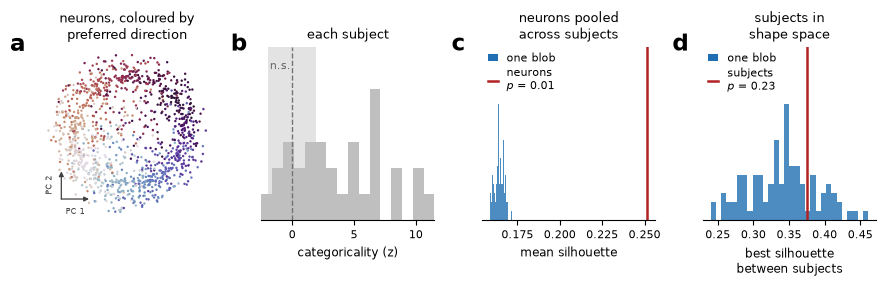

In [7]:
PANEL = 2.24
fig, axes = plt.subplots(1, 4, figsize=(4 * PANEL, 1.17 * PANEL))

# a. the ring, coloured by preferred direction
ax = axes[0]
sub = np.random.default_rng(0).choice(len(Y), 1200, replace=False)
ax.scatter(Y[sub, 0], Y[sub, 1], s=3, c=plt.cm.twilight(pref[sub] / (2 * np.pi)),
           edgecolor="none", rasterized=True)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)
plotting.pc_arrows(ax)
ax.set_title("neurons, coloured by\npreferred direction")

plotting.categoricality_hist(axes[1], z_cat, ns=NS)
axes[1].set_title("each subject")

plotting.null_hist(axes[2], b_obs, b_null, "mean silhouette",
                   label_null="one blob", label_obs="neurons", p=b_p)
axes[2].set_title("neurons pooled\nacross subjects")

plotting.null_hist(axes[3], c_obs, c_null, "best silhouette\nbetween subjects",
                   label_null="one blob", label_obs="subjects", p=c_p)
axes[3].set_title("subjects in\nshape space")

for ax, letter in zip(axes, "abcd"):
    plotting.panel_letter(ax, letter, dx=-22)
plotting.typeset(fig)
fig.tight_layout(w_pad=1.0)
plotting.save(fig, "hd_clustering_panels", folder=str(OUT))

## What it says

**a.** The neuron cloud is a ring, traced by preferred direction, which is uniform across
the population. Every subsequent number has to be read against that fact.

**b, c.** Both reject the single-Gaussian null, pooled by a very large margin. Neither is
evidence of cell types: the clusters they find are arcs of the ring, and the pooled null's
spread is so small that the comparison is a statement about the null's shape rather than
about the data's lumpiness. What these panels establish is that head-direction tuning is
strongly non-Gaussian, in the specific way a uniform ring is.

**d.** Subjects do not form types. The best silhouette between them is indistinguishable
from a Gaussian matched to their embedding, and the null chooses $k = 2$ in most of its
own draws, so the data's $k = 2$ carries little.

**What would answer the cell-type question properly.** Two things this notebook does not
do. Peak-aligning the curves removes the ring but costs part of the tuning-shape space --
aligning on the measured peak displaces skewed curves, since a skewed bump's maximum moves
with its skew. And testing whether *preferred directions themselves* are clustered needs a
uniform-on-the-circle null rather than a Gaussian in curve space; against a Gaussian, a
uniform ring already scores as strongly clustered, which is exactly the trap panels **b**
and **c** fall into.